# 03 — A/B Test on Subject Lines

Compare open rates between subject-line **Version_A** and **Version_B** and test for statistical significance with a **Chi-Square test of independence** (`scipy.stats`).

**Hypotheses:** H0 — subject line has no effect on open rate. H1 — it does. Significance threshold: *p < 0.05*.

In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/cleaned_email_data.csv')
ab = df[df.delivered==1]   # only delivered emails can be opened
ab.shape

(9498, 14)

## Step 5 — Build the contingency table

In [2]:
contingency = pd.crosstab(ab['subject_line'], ab['opened'])
contingency.columns = ['Not Opened','Opened']
contingency

,Not Opened,Opened
subject_line,,
Version_A,3281,1429
Version_B,3175,1613


In [3]:
rates = ab.groupby('subject_line')['opened'].mean()
print('Version_A open rate:', f'{rates["Version_A"]:.2%}')
print('Version_B open rate:', f'{rates["Version_B"]:.2%}')

Version_A open rate: 30.34%
Version_B open rate: 33.69%


## Run the Chi-Square test

In [4]:
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(ab['subject_line'], ab['opened']))
print(f'Chi2 statistic : {chi2:.4f}')
print(f'p-value        : {p:.6f}')
print(f'deg. freedom   : {dof}')
sig = p < 0.05
winner = rates.idxmax()
print('\nConclusion:', 'STATISTICALLY SIGNIFICANT — reject H0.' if sig else 'NOT significant — fail to reject H0.')
print('Winning subject line:', winner)

Chi2 statistic : 12.0768
p-value        : 0.000511
deg. freedom   : 1

Conclusion: STATISTICALLY SIGNIFICANT — reject H0.
Winning subject line: Version_B


## Visualize the result

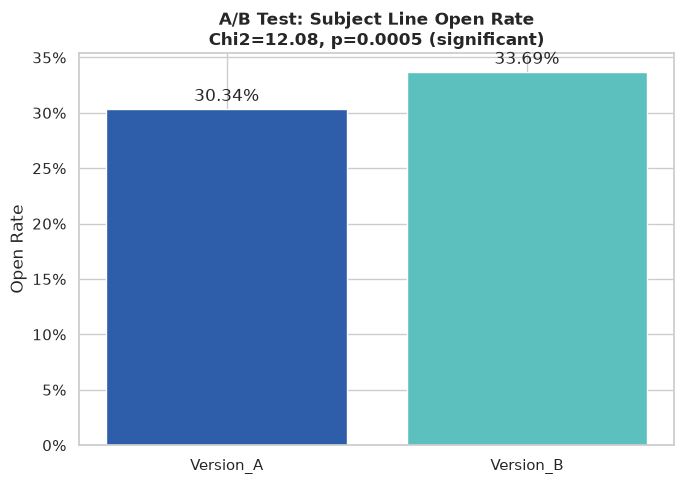

In [5]:
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(rates.index, rates.values, color=['#2E5EAA','#5BC0BE'], edgecolor='white')
ax.set_title(f'A/B Test: Subject Line Open Rate\nChi2={chi2:.2f}, p={p:.4f} ' + ('(significant)' if sig else '(not significant)'), weight='bold')
ax.set_ylabel('Open Rate'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
ax.bar_label(bars, labels=[f'{v:.2%}' for v in rates.values], padding=3)
plt.tight_layout(); plt.savefig('../visuals/ab_test_open_rate.png', dpi=120, bbox_inches='tight'); plt.show()

**Business decision:** If the result is significant, roll out the winning subject line across future sends; the open-rate lift compounds across the entire funnel. If not significant, continue testing with a larger sample before committing.